# UK Job Market Analysis — BA/DA Roles
**Author:** Mayank Joshi  
**Date:** March 2026  
**Goal:** Identify top skills, salary ranges, and work arrangements demanded by UK employers for BA/DA roles.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## 1. Load & Inspect Data

In [2]:
# Load the bundled sample: 25 UK BA/DA listings, Jan to Feb 2025. Small sample, so results are indicative only.
df = pd.read_csv('sample_listings.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (25, 6)
Columns: ['job_title', 'company', 'location', 'salary', 'description', 'date_posted']


,job_title,company,location,salary,description,date_posted
0,Business Analyst,Lloyds Banking Group,London EC2,£45000-£55000,SQL Excel Power BI Agile stakeholder managemen...,2025-01-10
1,Data Analyst,HSBC,London Canary Wharf,£42000-£52000,Python SQL Tableau data visualisation Excel Po...,2025-01-11
2,Senior Business Analyst,Barclays,London,£58000-£68000,SQL Agile Scrum Confluence Jira stakeholder ma...,2025-01-12
3,Data Analyst,NHS Digital,Manchester,£35000-£42000,SQL Python Excel Power BI healthcare data dash...,2025-01-13
4,Business Analyst,Tesco,Welwyn Garden City,£38000-£46000,SQL Excel Visio process improvement Agile BPMN...,2025-01-14


## 2. Data Cleaning

In [3]:
# Drop duplicates
df = df.drop_duplicates(subset=['job_title', 'company', 'location'])

# Standardise job titles
def classify_role(title):
    title = title.lower()
    if 'business analyst' in title or ' ba ' in title:
        return 'Business Analyst'
    elif 'data analyst' in title or ' da ' in title:
        return 'Data Analyst'
    elif 'bi ' in title or 'business intelligence' in title:
        return 'BI Analyst'
    else:
        return 'Other'

df['role_category'] = df['job_title'].apply(classify_role)

# Extract salary midpoint
def extract_salary_midpoint(salary_str):
    if pd.isna(salary_str):
        return None
    numbers = re.findall(r'[\d,]+', str(salary_str).replace(',', ''))
    numbers = [int(n) for n in numbers if len(n) >= 4]
    if len(numbers) >= 2:
        return (numbers[0] + numbers[1]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    return None

df['salary_midpoint'] = df['salary'].apply(extract_salary_midpoint)

# Map to UK regions
london_keywords = ['london', 'city of london', 'canary wharf', 'ec1', 'ec2', 'wc1', 'wc2', 'se1']
def map_region(location):
    if pd.isna(location):
        return 'Unknown'
    loc = location.lower()
    if any(k in loc for k in london_keywords):
        return 'London'
    elif any(k in loc for k in ['manchester', 'leeds', 'sheffield', 'liverpool']):
        return 'North West / Yorkshire'
    elif any(k in loc for k in ['birmingham', 'coventry', 'nottingham']):
        return 'Midlands'
    elif any(k in loc for k in ['edinburgh', 'glasgow', 'scotland']):
        return 'Scotland'
    elif 'remote' in loc:
        return 'Remote'
    else:
        return 'Other UK'

df['region'] = df['location'].apply(map_region)
print(f'Clean dataset: {df.shape[0]} listings')
df[['job_title', 'role_category', 'region', 'salary_midpoint']].head(10)

Clean dataset: 25 listings


,job_title,role_category,region,salary_midpoint
0,Business Analyst,Business Analyst,London,50000.0
1,Data Analyst,Data Analyst,London,47000.0
2,Senior Business Analyst,Business Analyst,London,63000.0
3,Data Analyst,Data Analyst,North West / Yorkshire,38500.0
4,Business Analyst,Business Analyst,Other UK,42000.0
5,Data Analyst,Data Analyst,London,55000.0
6,Business Analyst,Business Analyst,Midlands,40000.0
7,Senior Data Analyst,Data Analyst,Other UK,60000.0
8,Business Analyst,Business Analyst,London,44000.0
9,Data Analyst,Data Analyst,London,49000.0


## 3. Skills Demand Analysis

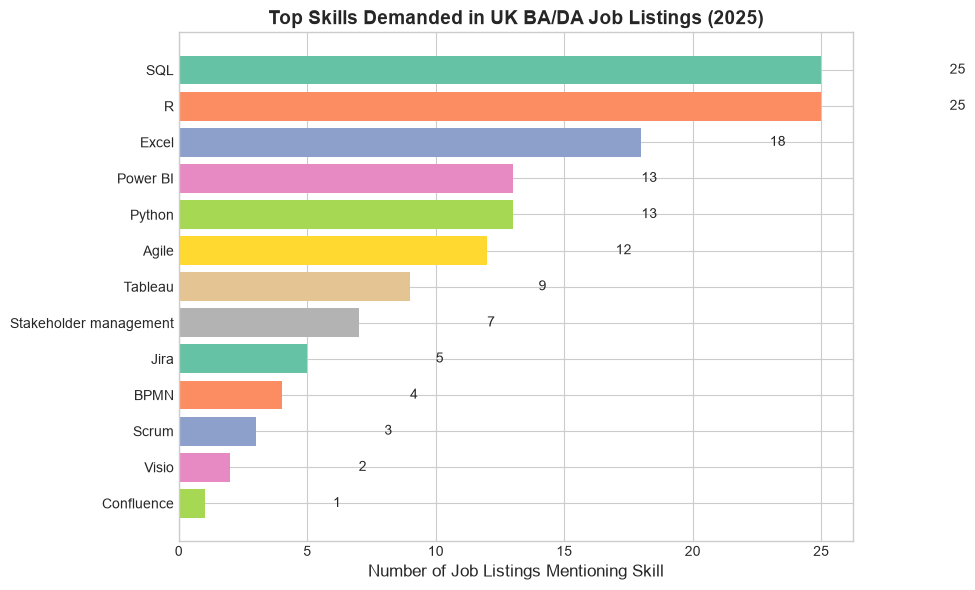

In [4]:
# Define skills to track
SKILLS = [
    'SQL', 'Excel', 'Power BI', 'Tableau', 'Python', 'R',
    'Jira', 'Confluence', 'Agile', 'Scrum', 'Azure', 'AWS',
    'Salesforce', 'SAP', 'Visio', 'BPMN', 'Stakeholder management'
]

def count_skills(description_series):
    counts = Counter()
    for desc in description_series.dropna():
        desc_lower = desc.lower()
        for skill in SKILLS:
            if skill.lower() in desc_lower:
                counts[skill] += 1
    return counts

skill_counts = count_skills(df['description'])
skills_df = pd.DataFrame(skill_counts.items(), columns=['Skill', 'Count'])
skills_df = skills_df.sort_values('Count', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(skills_df['Skill'], skills_df['Count'], color=sns.color_palette('Set2', len(skills_df)))
ax.set_xlabel('Number of Job Listings Mentioning Skill', fontsize=12)
ax.set_title('Top Skills Demanded in UK BA/DA Job Listings (2025)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar, count in zip(bars, skills_df['Count']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('visualisations/skills_demand.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Salary Distribution by Region

/var/folders/px/8n6v_pc54vv44d07b992jjt00000gn/T/ipykernel_21228/806623948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=salary_data, x='region', y='salary_midpoint',


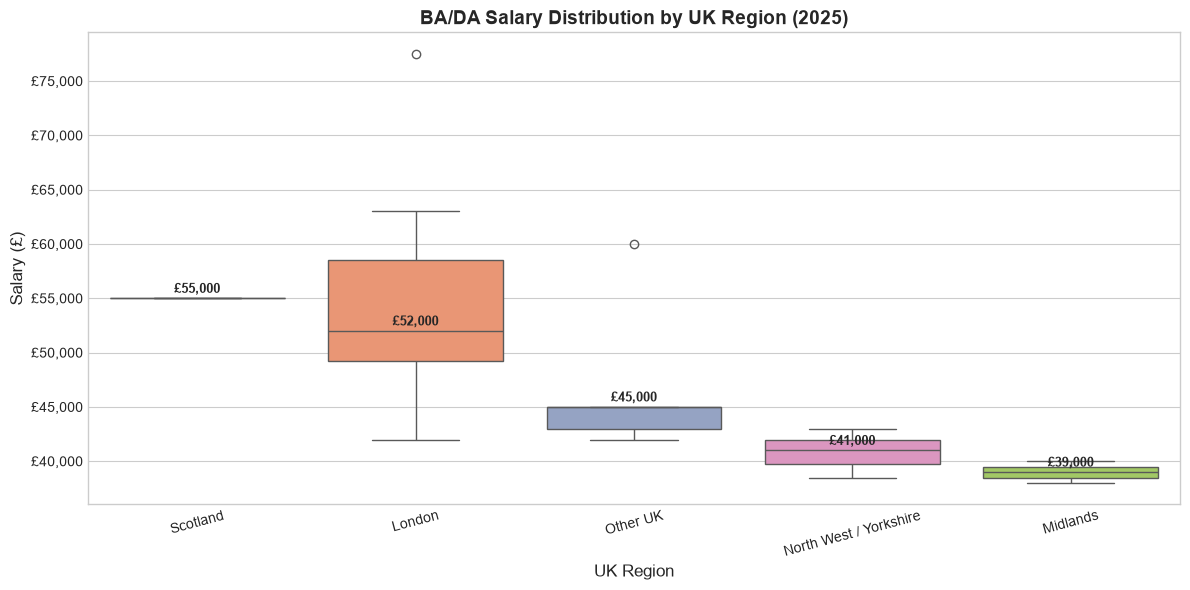

In [5]:
salary_data = df[df['salary_midpoint'].between(20000, 120000)]

fig, ax = plt.subplots(figsize=(12, 6))
regions_ordered = salary_data.groupby('region')['salary_midpoint'].median().sort_values(ascending=False).index

sns.boxplot(data=salary_data, x='region', y='salary_midpoint',
            order=regions_ordered, palette='Set2', ax=ax)

ax.set_xlabel('UK Region', fontsize=12)
ax.set_ylabel('Salary (£)', fontsize=12)
ax.set_title('BA/DA Salary Distribution by UK Region (2025)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Add median labels
medians = salary_data.groupby('region')['salary_midpoint'].median()
for i, region in enumerate(regions_ordered):
    ax.text(i, medians[region] + 500, f'£{medians[region]:,.0f}',
            ha='center', fontsize=9, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('visualisations/salary_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Work Arrangement Breakdown

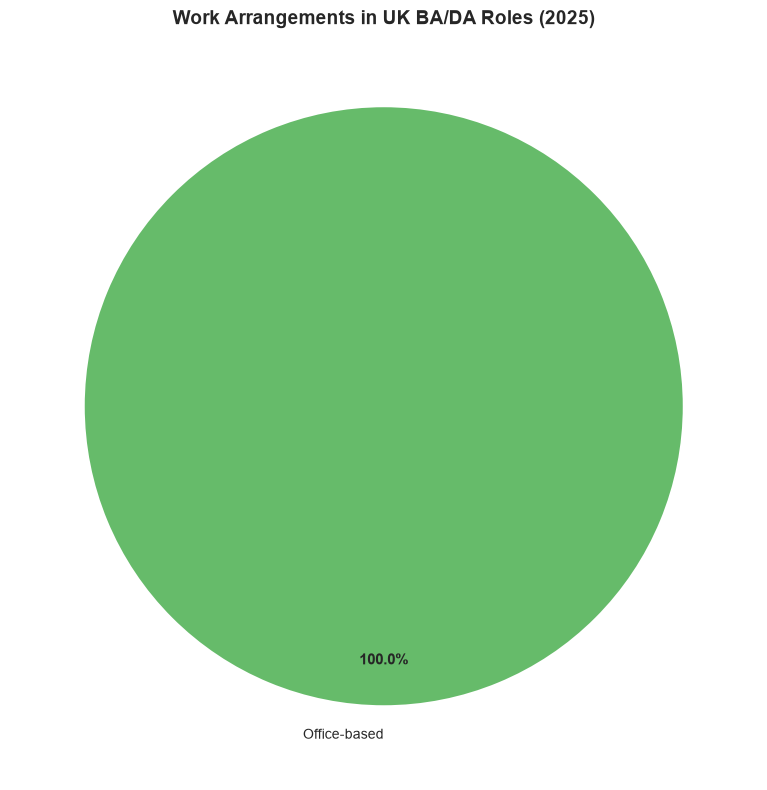

In [6]:
def classify_arrangement(row):
    text = str(row.get('description', '')) + ' ' + str(row.get('job_title', ''))
    text = text.lower()
    if 'fully remote' in text or 'remote only' in text:
        return 'Fully Remote'
    elif 'hybrid' in text:
        return 'Hybrid'
    elif 'remote' in text:
        return 'Remote/Flexible'
    else:
        return 'Office-based'

df['work_arrangement'] = df.apply(classify_arrangement, axis=1)

arrangement_counts = df['work_arrangement'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#66BB6A', '#42A5F5', '#FFA726', '#EF5350']
wedges, texts, autotexts = ax.pie(
    arrangement_counts.values,
    labels=arrangement_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title('Work Arrangements in UK BA/DA Roles (2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualisations/work_arrangements.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Export Clean Data for Tableau
Export the cleaned dataset as CSV to import into Tableau Public.

In [7]:
export_cols = ['job_title', 'role_category', 'company', 'region', 'salary_midpoint', 'work_arrangement']
df[export_cols].to_csv('cleaned_listings.csv', index=False)
print(f'Exported {len(df)} rows to cleaned_listings.csv')
print('\nNext step: Import cleaned_listings.csv into Tableau Public to build the interactive dashboard.')

Exported 25 rows to cleaned_listings.csv

Next step: Import cleaned_listings.csv into Tableau Public to build the interactive dashboard.
